In [1]:
# !pip install pandas

In [2]:
import pandas as pd

df = pd.DataFrame({
    'temperature': [10, 7, 4, 0],
    'sales'      : [30, 50, 60, 80]
})

display(df)

,temperature,sales
0,10,30
1,7,50
2,4,60
3,0,80


In [3]:
a = -4
b = 80

for i in range(len(df)):
    x = df.loc[i, 'temperature']
    pred = a * x + b
    print(f'X={x}일 때 예측값 = {a} * {x} + {b} = {pred}')
    
    y = df.loc[i, 'sales']
    print(f'찐 y={y}')
    
    error = y - pred
    print(f'오차 = {y}-{pred}={error}', end='\n\n')

X=10일 때 예측값 = -4 * 10 + 80 = 40
찐 y=30
오차 = 30-40=-10

X=7일 때 예측값 = -4 * 7 + 80 = 52
찐 y=50
오차 = 50-52=-2

X=4일 때 예측값 = -4 * 4 + 80 = 64
찐 y=60
오차 = 60-64=-4

X=0일 때 예측값 = -4 * 0 + 80 = 80
찐 y=80
오차 = 80-80=0



In [4]:
a = -4
b = 80

square_sum = 0

for i in range(len(df)):
    x = df.loc[i, 'temperature']
    y = df.loc[i, 'sales']
    pred = a * x + b
    error = pred - y
    error_square = error ** 2
    square_sum = square_sum + error_square
    
n = len(df)
cost = square_sum / n

print(f'오차 제곱 합: {square_sum}')
print(f'데이터 개수: {n}')
print(f'Cost: {cost:.4f}')

오차 제곱 합: 120
데이터 개수: 4
Cost: 30.0000


In [5]:
def calculate_cost(a, b):
    
    square_sum = 0 # 오차 제곱의 합(초기값: 0)
    for i in range(len(df)):
        x = df.loc[i, 'temperature']
        y = df.loc[i, 'sales']
        pred = a * x + b
        error = pred - y
        error_square = error**2
        square_sum = square_sum + error_square
    
    n = len(df)
    cost = square_sum / n
    
    return cost

print('calculate_cost(-4, 80) =', calculate_cost(-4, 80))

calculate_cost(-4, 80) = 30.0


In [6]:
cost1 = calculate_cost(-4, 80)
cost2 = calculate_cost(-4.9, 81)

print(f'Y = -4X + 80 의 Cost: {cost1:.4f}')
print(f'Y = -4.9X + 81 의 Cost: {cost2:.4f}')

Y = -4X + 80 의 Cost: 30.0000
Y = -4.9X + 81 의 Cost: 4.4625


In [7]:
a_values = [-6, -5, -4, -3, -2]
b = 80

cost_values = []

for a in a_values:
    cost = calculate_cost(a, b)
    cost_values.append(cost)
    print(f'a={a}, b={b}, Cost={cost:.4f}')

a=-6, b=80, Cost=65.0000
a=-5, b=80, Cost=6.2500
a=-4, b=80, Cost=30.0000
a=-3, b=80, Cost=136.2500
a=-2, b=80, Cost=325.0000


In [8]:
# !pip install matplotlib

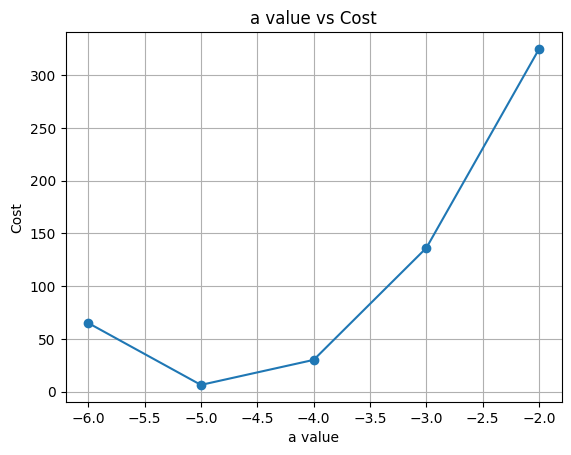

In [9]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(a_values, cost_values, marker='o')
plt.title('a value vs Cost')
plt.xlabel('a value')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

In [10]:
b = 80

a = -4
cost = calculate_cost(a, b)
print(f'a={a}, b={b}, Cost={cost:.4f}')

a = -4.5
cost = calculate_cost(a, b)
print(f'a={a}, b={b}, Cost={cost:.4f}')

a = -5
cost = calculate_cost(a, b)
print(f'a={a}, b={b}, Cost={cost:.4f}')

a=-4, b=80, Cost=30.0000
a=-4.5, b=80, Cost=7.8125
a=-5, b=80, Cost=6.2500


In [11]:
a = -4
b = 80
learning_rate = 0.001
epochs = 1000

n = len(df)
cost_history = []

initial_a = a
initial_b = b
initial_cost = calculate_cost(a, b)
print(f'학습 전 Cost: {initial_cost:.4f}')

학습 전 Cost: 30.0000


In [13]:
for epoch in range(epochs):
    
    grad_a = 0
    grad_b = 0
    
    for i in range(len(df)):
        x = df.loc[i, 'temperature']
        y = df.loc[i, 'sales']
        
        pred = a * x + b
        
        pred_minus_actual = pred - y
        
        grad_a = grad_a + pred_minus_actual * x
        grad_b = grad_b + pred_minus_actual
        
    
    n = len(df)
    grad_a = grad_a / n
    
    a = a - 1*(learning_rate * grad_a)
    b = b - 1*(learning_rate * grad_b)
    
    cost = calculate_cost(a, b)
    cost_history.append(cost)
    
    if epoch % 100 == 0:
        print(f'epoch={epoch}, Cost={cost:.4f}, a={a:.4f}, b={b:.4f}')

epoch=0, Cost=4.3554, a=-4.8101, b=80.1817
epoch=100, Cost=4.3515, a=-4.8136, b=80.2085
epoch=200, Cost=4.3485, a=-4.8167, b=80.2322
epoch=300, Cost=4.3462, a=-4.8195, b=80.2532
epoch=400, Cost=4.3444, a=-4.8219, b=80.2716
epoch=500, Cost=4.3429, a=-4.8240, b=80.2879
epoch=600, Cost=4.3418, a=-4.8259, b=80.3023
epoch=700, Cost=4.3410, a=-4.8276, b=80.3151
epoch=800, Cost=4.3403, a=-4.8291, b=80.3263
epoch=900, Cost=4.3398, a=-4.8304, b=80.3362


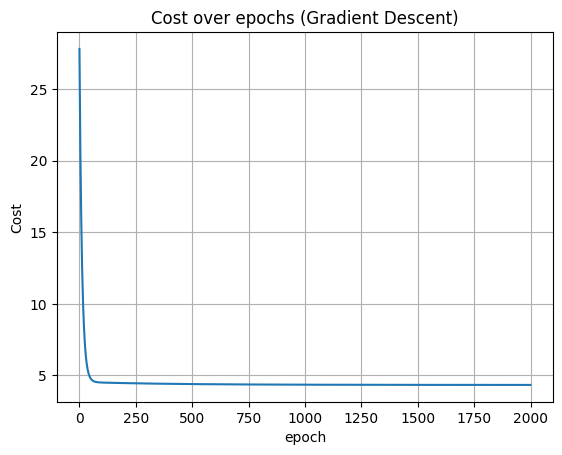

In [15]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(range(len(cost_history)), cost_history)
plt.title('Cost over epochs (Gradient Descent)')
plt.xlabel('epoch')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

In [18]:
final_a = a
final_b = b
final_cost = calculate_cost(final_a, final_b)

print('학습 전')
print(f'a = {initial_a:.4f}')
print(f'b = {initial_b:.4f}')
print(f'Cost = {initial_cost:.4f}')

print('\n학습 후')
print(f'a = {final_a:.4f}')
print(f'b = {final_b:.4f}')
print(f'Cost = {final_cost:.4f}')

학습 전
a = -4.0000
b = 80.0000
Cost = 30.0000

학습 후
a = -4.8315
b = 80.3449
Cost = 4.3394
